## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback



## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [ ]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [ ]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

#### Section 2 — Epoch AI: Training compute vs parameters

This section examines whether larger models (more `Parameters`) tend to require more `Training compute (FLOP)` in the Epoch dataset. Both variables span many orders of magnitude, so we analyze them on a base-10 log scale. Because training compute is missing for a substantial fraction of rows, any compute-vs-parameter relationship is conditional on models with reported compute values. We report coverage first, then inspect univariate distributions, and finally plot compute versus parameters with a fitted trend.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

epoch_df = pd.read_json("data/Output/epoch_ai_parameters.ndjson", lines=True)
print(f"Epoch rows: {len(epoch_df):,} | columns: {epoch_df.shape[1]}")

required_cols = ["Parameters", "Training compute (FLOP)", "Domain", "Publication date"]
missing_required = [col for col in required_cols if col not in epoch_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

missing_cols = [
    "Parameters",
    "Training compute (FLOP)",
    "Training dataset size (total)",
    "Batch size",
    "Training chip-hours",
]
missing_tbl = pd.DataFrame({
    "missing_count": epoch_df[missing_cols].isna().sum(),
    "missing_frac": epoch_df[missing_cols].isna().mean(),
}).sort_values("missing_frac", ascending=False)

compute_reported = int(epoch_df["Training compute (FLOP)"].notna().sum())
print(f"Rows with non-missing training compute: {compute_reported:,} / {len(epoch_df):,}")
missing_tbl


Epoch rows: 1,403 | columns: 14
Rows with non-missing training compute: 815 / 1,403


,missing_count,missing_frac
Training chip-hours,1267,0.903065
Batch size,1200,0.855310
Training dataset size (total),674,0.480399
Training compute (FLOP),588,0.419102
Parameters,0,0.000000


#### Metadata Interpretation:
Based on the above metadata, Training compute is missing for a large share of models, so all compute-focused EDA below uses only the subset with reported compute values. If missingness is systematic (for example, certain model families reporting less often), the observed relationship can be biased relative to the full population.


In [2]:
# Positive-value filtering for log transforms
# Role: prepare a valid, analysis-ready subset for all downstream EDA plots and stats.
n_total = len(epoch_df)
n_params_valid = int(epoch_df["Parameters"].gt(0).sum())
n_compute_valid = int(epoch_df["Training compute (FLOP)"].gt(0).sum())

# Keep only rows where Parameters are strictly positive so log10 is defined.
epoch = epoch_df.loc[epoch_df["Parameters"].gt(0)].copy()
epoch["log10_params"] = np.log10(epoch["Parameters"])

# Restrict to rows with positive compute values; this subset drives compute-related plots.
epoch_compute = epoch.loc[epoch["Training compute (FLOP)"].gt(0)].copy()
epoch_compute["log10_train_flop"] = np.log10(epoch_compute["Training compute (FLOP)"])

n_pair = len(epoch_compute)

corr_log = epoch_compute["log10_params"].corr(epoch_compute["log10_train_flop"])
slope, intercept = np.polyfit(epoch_compute["log10_params"], epoch_compute["log10_train_flop"], 1)
print(f"log10 correlation (r): {corr_log:.3f}")
print(f"fitted line: log10_train_flop = {slope:.3f} * log10_params + {intercept:.3f}")


log10 correlation (r): 0.875
fitted line: log10_train_flop = 1.724 * log10_params + 5.208


#### Preprocessing Cell:
The above cell builds the clean subset used by every graph below. We keep only strictly positive values for `Parameters` and `Training compute (FLOP)` because `log10` is undefined for zero or negative values, then compute `n_pair`, correlation, and line-fit values that are reused in the relationship plot and its annotation. In short, this is the quality-control and feature-prep step that makes the downstream EDA valid and comparable.


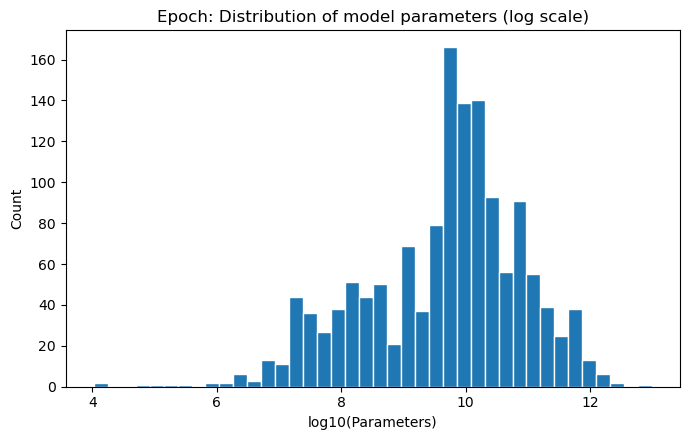

In [3]:
# Distribution of model parameters (log10)
plt.figure(figsize=(7, 4.5))
plt.hist(epoch["log10_params"].dropna(), bins=40, edgecolor="white")
plt.xlabel("log10(Parameters)")
plt.ylabel("Count")
plt.title("Epoch: Distribution of model parameters (log scale)")
plt.tight_layout()
plt.show()


#### Parameters distribution:
This first graph addresses the Section 2 setup by showing how model size is distributed before comparing it to compute. Most models cluster in specific log10 parameter bands rather than being evenly spread, which suggests the dataset is concentrated around common model scales. This matters because the relationship analysis should be interpreted in the context of where model-size density is highest.


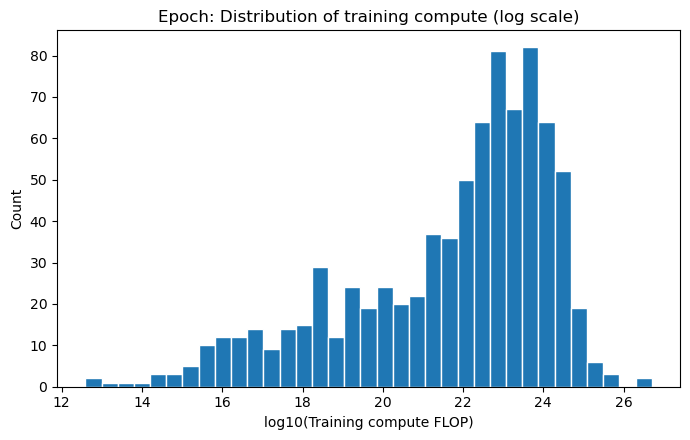

In [4]:
# Distribution of training compute (log10)
plt.figure(figsize=(7, 4.5))
plt.hist(epoch_compute["log10_train_flop"].dropna(), bins=35, edgecolor="white")
plt.xlabel("log10(Training compute FLOP)")
plt.ylabel("Count")
plt.title("Epoch: Distribution of training compute (log scale)")
plt.tight_layout()
plt.show()


#### Training compute distribution:

This second graph complements the first by showing the compute side of the same question, also on a log scale. Training compute is similarly broad across orders of magnitude, but this view is based only on rows with reported compute values, matching the missingness caveat in the section blurb. Together, the first two plots justify using a log-log relationship plot instead of raw-scale comparisons.


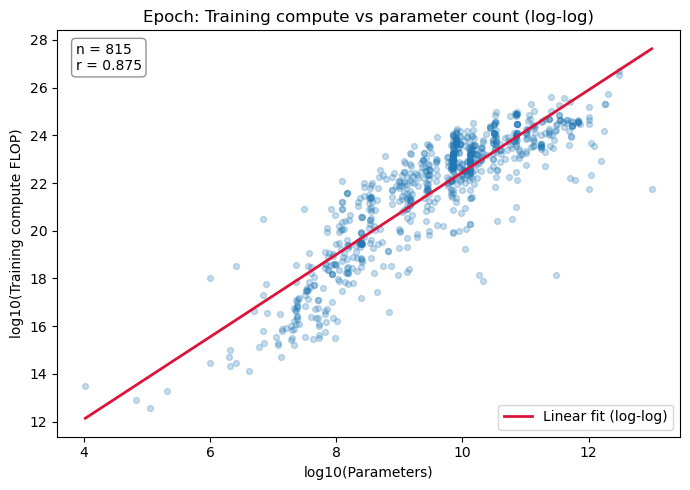

In [5]:
# Relationship: parameters vs training compute (both log10)
x = epoch_compute["log10_params"].to_numpy()
y = epoch_compute["log10_train_flop"].to_numpy()
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.25, s=18)
plt.plot(x_line, y_line, color="crimson", linewidth=2, label="Linear fit (log-log)")
plt.xlabel("log10(Parameters)")
plt.ylabel("log10(Training compute FLOP)")
plt.title("Epoch: Training compute vs parameter count (log-log)")
plt.legend()
plt.text(
    0.03,
    0.97,
    f"n = {n_pair:,}\nr = {corr_log:.3f}",
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85, "edgecolor": "gray"},
)
plt.tight_layout()
plt.show()


#### Relationship graph:

This final graph directly answers the question at the beginning of Section 2: as parameter count increases, required training compute also tends to increase. The upward trend line and strong reported correlation indicate a clear positive association in log space, not just a few outliers driving the pattern. Since this uses the reported-compute subset, the result is best interpreted as a strong conditional relationship rather than a guaranteed pattern for all models in the full dataset.


## Section 3 -- Huggingface.co OpenLLMLeaderboard

Huggingface uniquely gives a direct environmental variable we can compare models to. Additionally, as a leaderboard, they include metrics for performace across various LLM tasks, as well as normalized and average scores for each of them.
Packages are first imported, and the data made ready for analysis.

In [1]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# load huggingface dataset
src = "./data/Output/hf_parameters_co2.ndjson"
hf = pl.scan_ndjson(src)

# unnest specific benchmarks (json origin)
benchmarks = ["bbh", "gpqa", "ifeval", "math", "mmlu_pro", "musr",]
for bench in benchmarks:
    hf = hf.with_columns(pl.col(bench).list.first().alias(bench))
    hf = hf.unnest(bench, separator="_")

# drop unnecesscary name cols
hf = hf.drop([col for col in hf.collect_schema().names() if "_name" in col])

# drop nulls for data we look at. Previous drops only uncluded nulls for parameter counts. 
# Collects dataframe into eager.
hf = hf.drop_nulls(pl.selectors.matches("co2_cost|_value")).collect()
x_vars=[
    "parameters",
    "bbh_value",
    "gpqa_value",
    "ifeval_value",
    "math_value",
    "mmlu_pro_value",
    "musr_value",
]

The first step is to take a glimpse at the data. polars.describe() generates summary statistics, which we show the entirety of by changing the config.
We are also curious at what type of relationship these variables have with one another, but most importantly, the co2_cost variable. 

In [2]:
# Describe variables
with pl.Config(tbl_cols=100, tbl_width_chars=1000):
    print("Summary Statistics for HuggingFace Dataset")
    print(hf.drop([
        "architecture",
        "model",
        "precision",
        "name",

    ]).describe())

normalized_numeric = [
    "co2_cost",
    "parameters",
    "average_score",
    "bbh_normalized_score",
    "gpqa_normalized_score",
    "ifeval_normalized_score",
    "math_normalized_score",
    "mmlu_pro_normalized_score",
    "musr_normalized_score",
]


# Correlation Matrix
corr_df = hf.with_columns([
    pl.col('co2_cost').log1p().alias('log_co2'),
])
corr_df = corr_df.select(["log_co2"] + [col for col in normalized_numeric if col not in ["co2_cost"]]).corr()
with pl.Config(tbl_cols=100, tbl_width_chars=1000):
    print("Correlation Matrix for Numerical Variables")
    print(corr_df)

Summary Statistics for HuggingFace Dataset
shape: (9, 16)
┌────────────┬───────────────┬────────────┬────────────┬───────────┬──────────────────────┬────────────┬───────────────────────┬──────────────┬─────────────────────────┬────────────┬───────────────────────┬────────────────┬───────────────────────────┬────────────┬───────────────────────┐
│ statistic  ┆ average_score ┆ co2_cost   ┆ parameters ┆ bbh_value ┆ bbh_normalized_score ┆ gpqa_value ┆ gpqa_normalized_score ┆ ifeval_value ┆ ifeval_normalized_score ┆ math_value ┆ math_normalized_score ┆ mmlu_pro_value ┆ mmlu_pro_normalized_score ┆ musr_value ┆ musr_normalized_score │
│ ---        ┆ ---           ┆ ---        ┆ ---        ┆ ---       ┆ ---                  ┆ ---        ┆ ---                   ┆ ---          ┆ ---                     ┆ ---        ┆ ---                   ┆ ---            ┆ ---                       ┆ ---        ┆ ---                   │
│ str        ┆ f64           ┆ f64        ┆ f64        ┆ f64       ┆ f64   

Immediately, we have some insights into "co2_cost". We can see the results are all clustered around the single-digit mark, but with significant outliers. Each benchmark and average is also present, allowing us to draw some comparisons between cost, parameter, and co2_cost.

Notice the correlation matrix generated uses "log_co2", as the original "co2_cost" is similar to an ~Exponential() distribution.
Below, let's now look at the distribution of the "co2_cost" in question, as well as in log form.

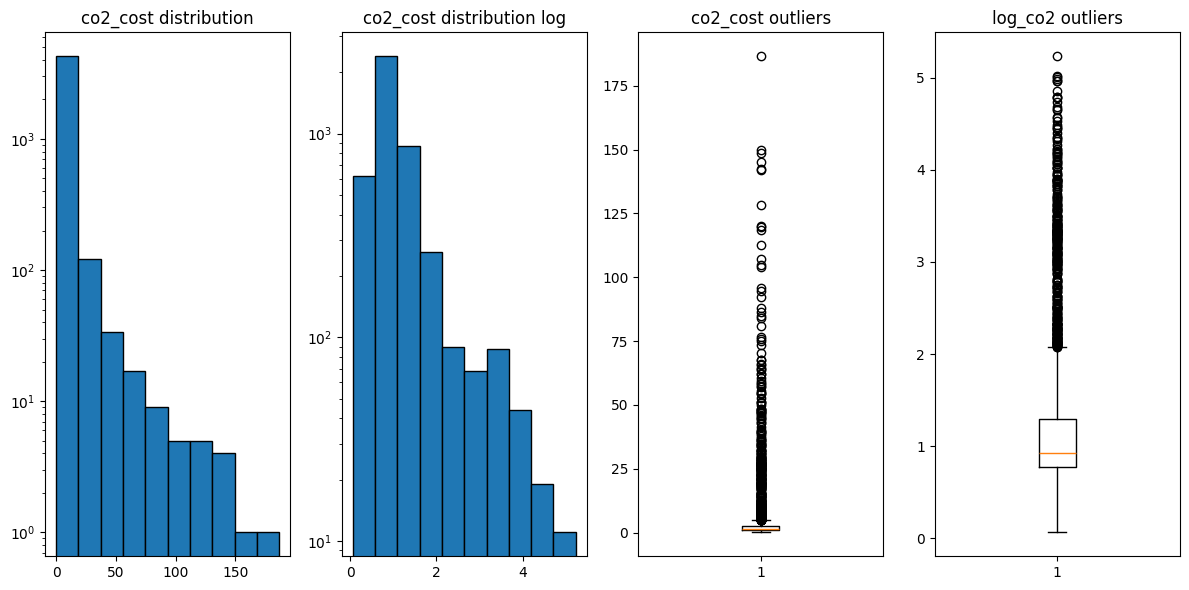

In [3]:
co2 = hf.select("co2_cost").to_numpy().flatten()

# generate plots to look at co2_cost
fig, axs = plt.subplots(1, 4, figsize=(12, 6))
axs[0].hist(co2, edgecolor="black")
axs[0].set_title("co2_cost distribution")
axs[0].set_yscale("log")

log = np.log1p(co2)
axs[1].hist(log, edgecolor="black")
axs[1].set_title("co2_cost distribution log")
axs[1].set_yscale("log")

axs[2].boxplot(co2, vert=True)
axs[2].set_title('co2_cost outliers')

axs[3].boxplot(log, vert=True)
axs[3].set_title('log_co2 outliers')

plt.tight_layout()
plt.show()

The left two plots illustrate the distribution as a histogram, with a logscale for y. We can see the aformentioned exponential-like distribution, where even as a log scale we see heavy-left leaning data. The right 2 plots show outliers, which matplotlib illustrates as circles for entries beyond Quartile 3 + 1.5% of Inter-Quartile Range. Even in log form, there are several outliers.

Taking a step back, we can look temporarily at how HuggingFace generates this "cost_co2" metric: 

*The [sic] calculate_co2_emissions() function estimates CO₂ emissions in kilograms for a given evaluation time in seconds, assuming the workload is running on 8 NVIDIA H100 SXM GPUs in Northern Virginia.*

Their calculations are based on runtime, and variables for power consumption per time, cost of power, co2 emissions per kWh.
In this context, these exponential results make sense: Newer models face a Pareto-paradox where improvements will cost more time and resources for less overall improvement. But by how much? While we don't get to this question in this section, this is the question we are trying to answer.

Next, let's look at the numerical variables for benchmarks.

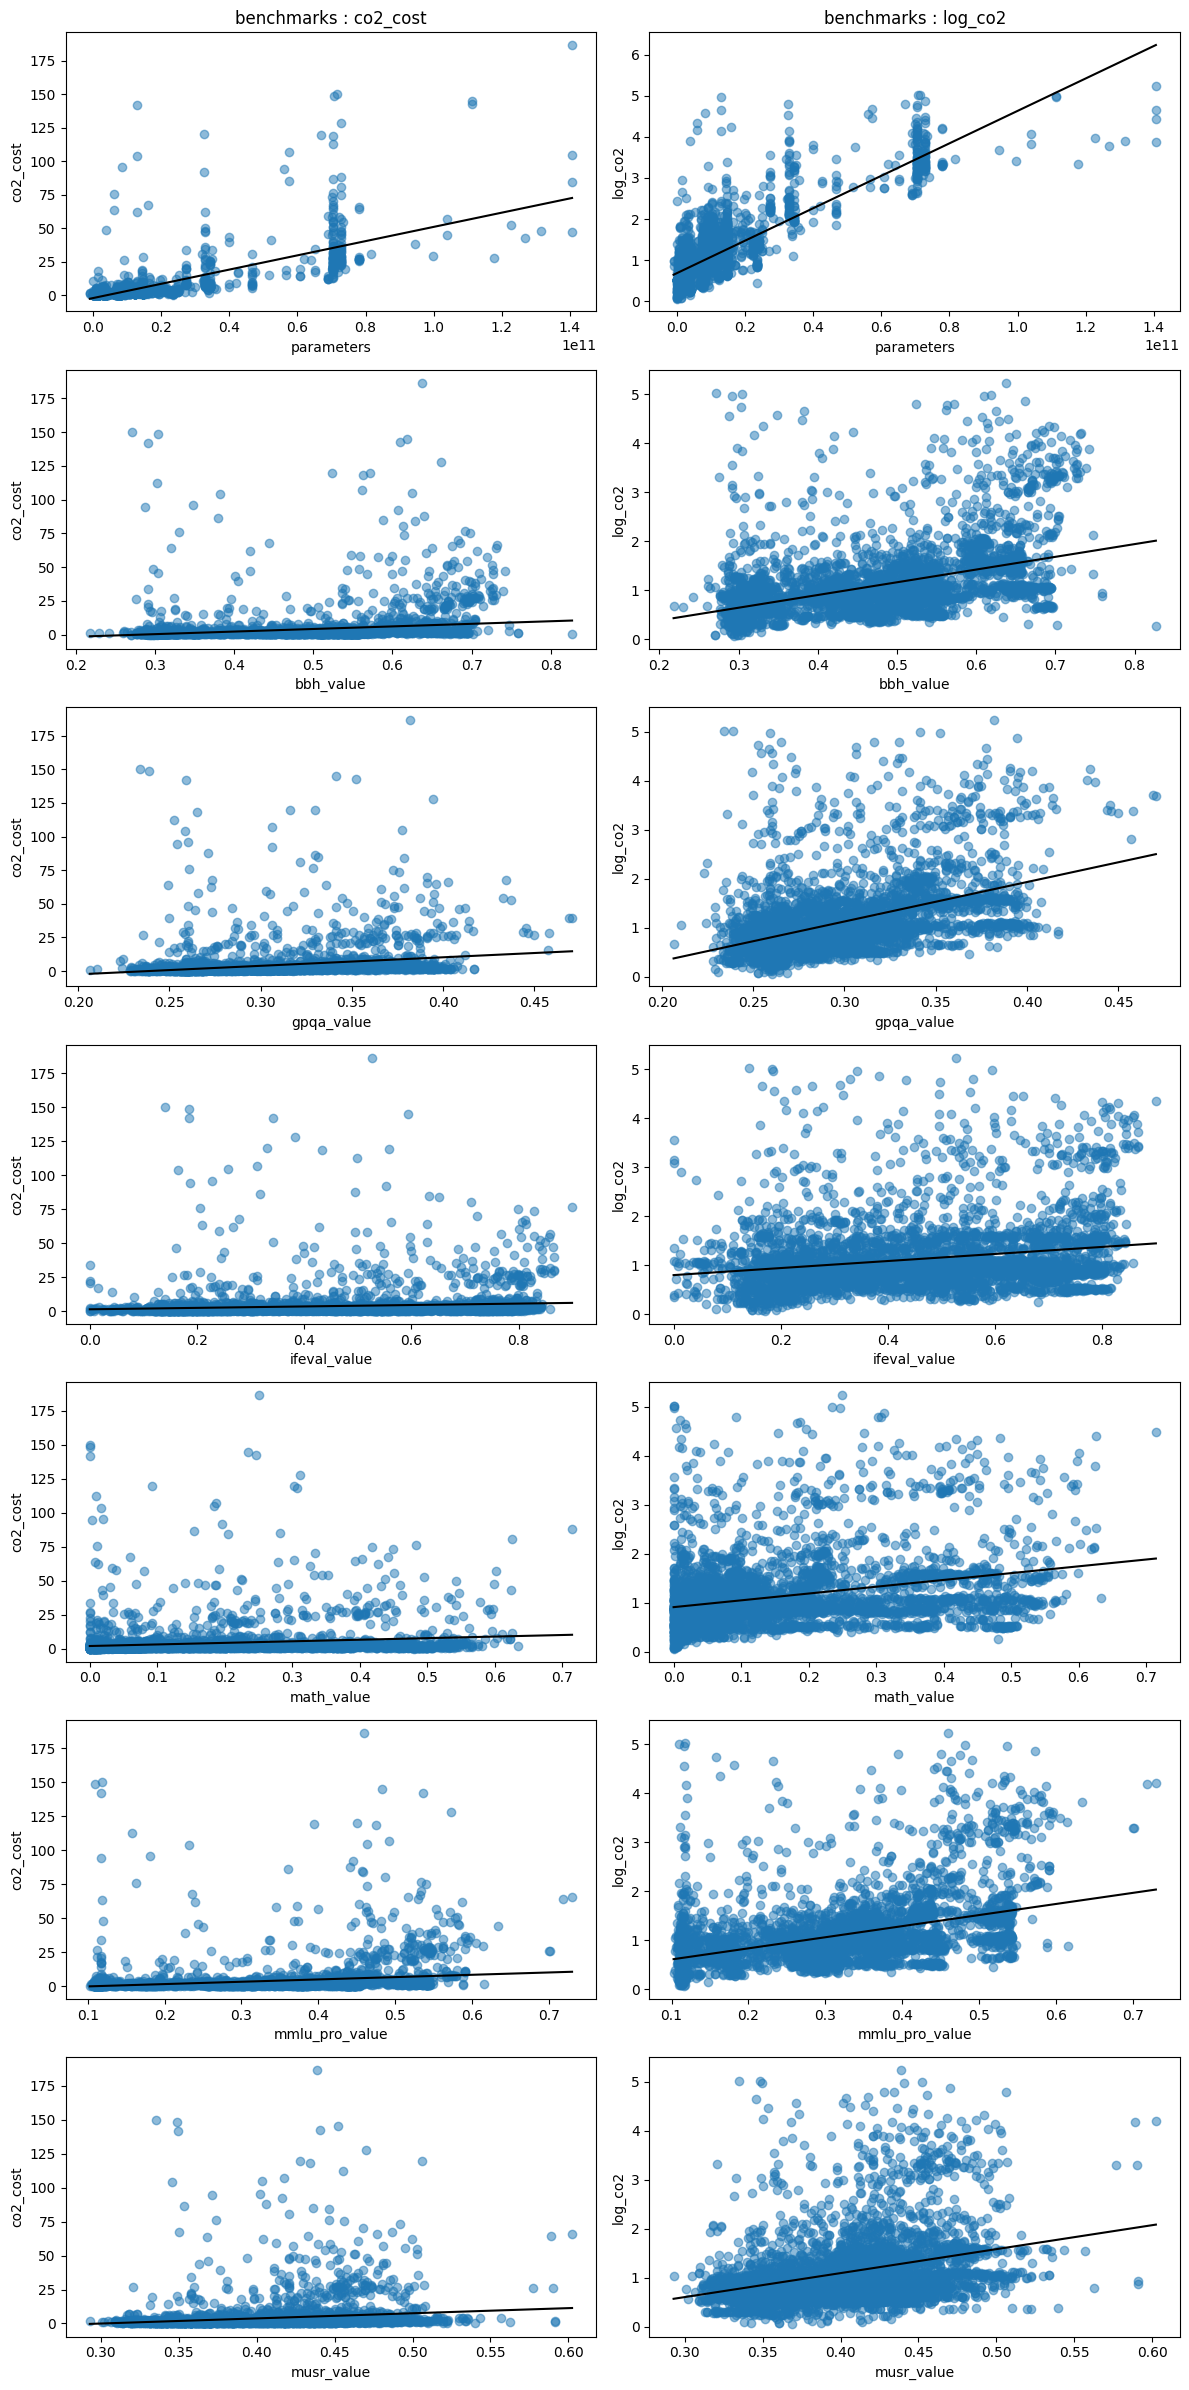

In [4]:
# This code below generates benchmark to co2 subplots, vertically.
fig, axs = plt.subplots(len(x_vars), 2, figsize=(12, 24))
axs = axs.flatten(order="F")
axs[0].set_title("benchmarks : co2_cost")
axs[7].set_title("benchmarks : log_co2")
for var in range(len(x_vars)):
    x = hf.select(x_vars[var]).to_numpy().flatten()
    m, b = np.polyfit(x, co2, 1)
    regline = np.linspace(x.min(), x.max())
    axs[var].scatter(hf.select(x_vars[var]).to_numpy(), co2, alpha=0.5)
    axs[var].plot(regline, m*regline+b, color="black")
    axs[var].set_xlabel(x_vars[var])
    axs[var].set_ylabel(f"co2_cost")

for var in range(len(x_vars)):
    x = hf.select(x_vars[var]).to_numpy().flatten()
    m, b = np.polyfit(x, log, 1)
    regline = np.linspace(x.min(), x.max())
    axs[var+len(x_vars)].scatter(hf.select(x_vars[var]).to_numpy(), log, alpha=0.5)
    axs[var+len(x_vars)].plot(regline, m*regline+b, color="black")
    axs[var+len(x_vars)].set_xlabel(x_vars[var])
    axs[var+len(x_vars)].set_ylabel(f"log_co2")


plt.tight_layout()
plt.show()

From this analysis, we can ascertain a relationship between co2_cost and parameters, as well as co2_cost and benchmarks. Going forward in analysis, we will explore this relationship closer.

Next let's take a glimpse at the 2 catagorical variables we have, architecture of the LLM and Precision. Architecture is for families of models, and precision is the precision the model works at, demonstrating a tradeoff between accuracy and speed.

In [5]:
print("List of architectures in HuggingFace Dataset")
print(hf.select(pl.col("architecture")).unique().sort(by="architecture").to_numpy())

List of architectures in HuggingFace Dataset
[['']
 ['?']
 ['AriaForConditionalGeneration']
 ['BloomForCausalLM']
 ['ChatGLMModel']
 ['ChatGLMModelM']
 ['Cohere2ForCausalLM']
 ['CohereForCausalLM']
 ['DbrxForCausalLM']
 ['DeciLMForCausalLM']
 ['DeepseekForCausalLM']
 ['ExaoneForCausalLM']
 ['FalconForCausalLM']
 ['FalconMambaForCausalLM']
 ['GPT2LMHeadModel']
 ['GPTJForCausalLM']
 ['GPTNeoForCausalLM']
 ['GPTNeoXForCausalLM']
 ['Gemma2ForCausalLM']
 ['Gemma2ForSequenceClassification']
 ['GemmaForCausalLM']
 ['GemmaModel']
 ['GlmForCausalLM']
 ['GraniteForCausalLM']
 ['GraniteMoeForCausalLM']
 ['HeliumForCausalLM']
 ['HymbaForCausalLM']
 ['InternLM2ForCausalLM']
 ['JambaForCausalLM']
 ['LLMForSequenceRegression']
 ['LlamaForCausalLM']
 ['LlamaForRewardModelWithGating']
 ['LlamaForSequenceClassification']
 ['LlamaMedITForCausalLM']
 ['MPTForCausalLM']
 ['MT5ForConditionalGeneration']
 ['MistralForCausalLM']
 ['MixtralForCausalLM']
 ['MllamaForConditionalGeneration']
 ['NemotronForCausalL

Architecture isn't very informative, and is less useful with many categories and not many models in each category, however can be used as a point of comparison.
Precision only has 3 categories, and we can illustrate some differences between them.

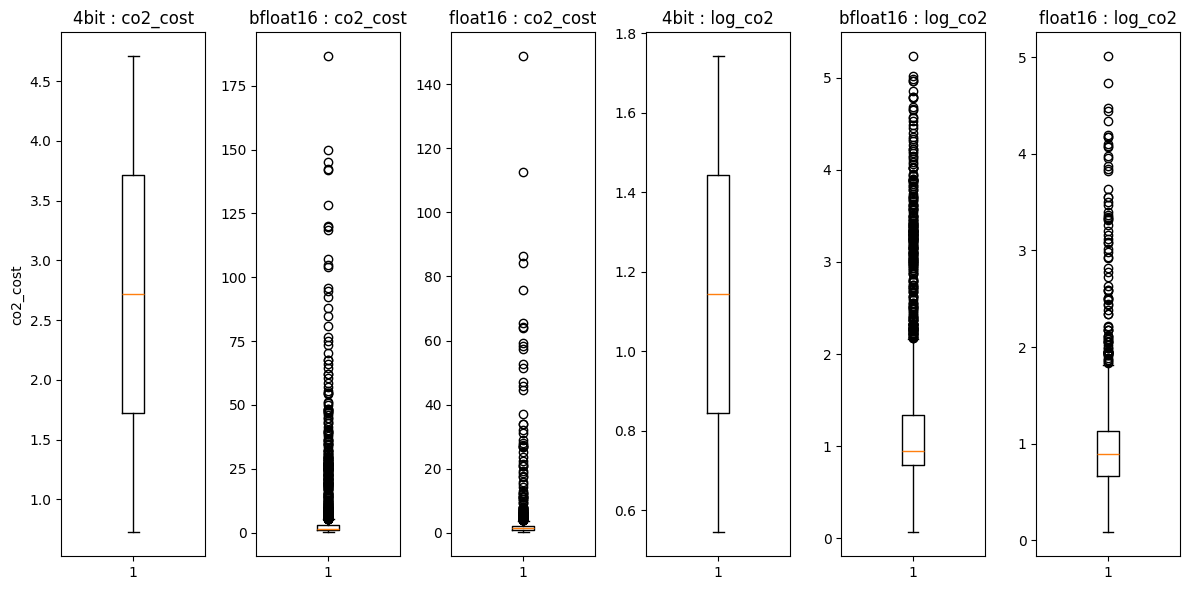

In [6]:
# Catagorical Variable analysis
fig, axs = plt.subplots(1, 6, figsize=(12, 6))
log = hf.with_columns([
    pl.col("co2_cost").log1p().alias("log_co2")
])
precision = hf.select("precision").unique().sort(by="precision").to_numpy().flatten()

axs[0].set_ylabel("co2_cost")
axs[0].set_title("Precision : co2_cost")

for cat in range(len(precision)):
    axs[cat].boxplot(hf.filter(pl.col("precision")==precision[cat]).select("co2_cost"))
    axs[cat].set_title(f"{precision[cat]} : co2_cost")

for cat in range(len(precision)):
    axs[cat+3].boxplot(log.filter(pl.col("precision")==precision[cat]).select("log_co2"))
    axs[cat+3].set_title(f"{precision[cat]} : log_co2")


plt.tight_layout()
plt.show()

Although 4bit only has a few entries, we later can draw comparisons between the other categories of "bfloat16" and "float16". 

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them